In [5]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))
from src import economics

RAW = Path("..") / "data" / "raw"
PROC = Path("..") / "data" / "processed"
REP = Path("..") / "reports"

In [6]:
df = pd.read_csv(PROC / "evidence_scored.csv")
wb = pd.read_excel(RAW / "prices_wb.xlsx")
wb = economics.add_month_price(wb)
wb = economics.add_categories(wb)
tier = economics.tier_table(wb)
tier.head(10)

⚠️ Подозрительно дорогие — проверь фасовку:
        добавка                                            продукт  \
4       Омега-3                      РеалКапс Омега-3 капс 1,4 N90   
46       Ежовик  Сашера-мед Ежовик гребенчатый с лецитином для ...   
79    CDP-холин   Рекогнан раствор для приема внутрь 100 мг мл ...   
95     Куркумин  Куркумин Куркумин 50 мг липосомальный капсулы ...   
144  Пикногенол              swanson Пикногенол, 100 мг, 30 капсул   

     единиц_в_упаковке  цена_мес  
4                    3   31920.0  
46                   2   28290.0  
79                  10    5472.0  
95                  30    5106.0  
144                 30    6418.0  


категория,эконом,средний,премиум,переплата_в_раз
добавка,,,,
Омега-3,197.0,543.0,3270.0,16.6
Куркумин,342.0,820.0,1683.0,4.9
B12,125.0,262.0,548.0,4.4
Пикногенол,1052.0,1718.0,4336.0,4.1
Ежовик,306.0,539.0,1214.0,4.0
Цинк,192.0,532.0,765.0,4.0
Бакопа,262.0,552.0,934.0,3.6
CoQ10,241.0,374.0,864.0,3.6
Ресвератрол,238.0,599.0,826.0,3.5


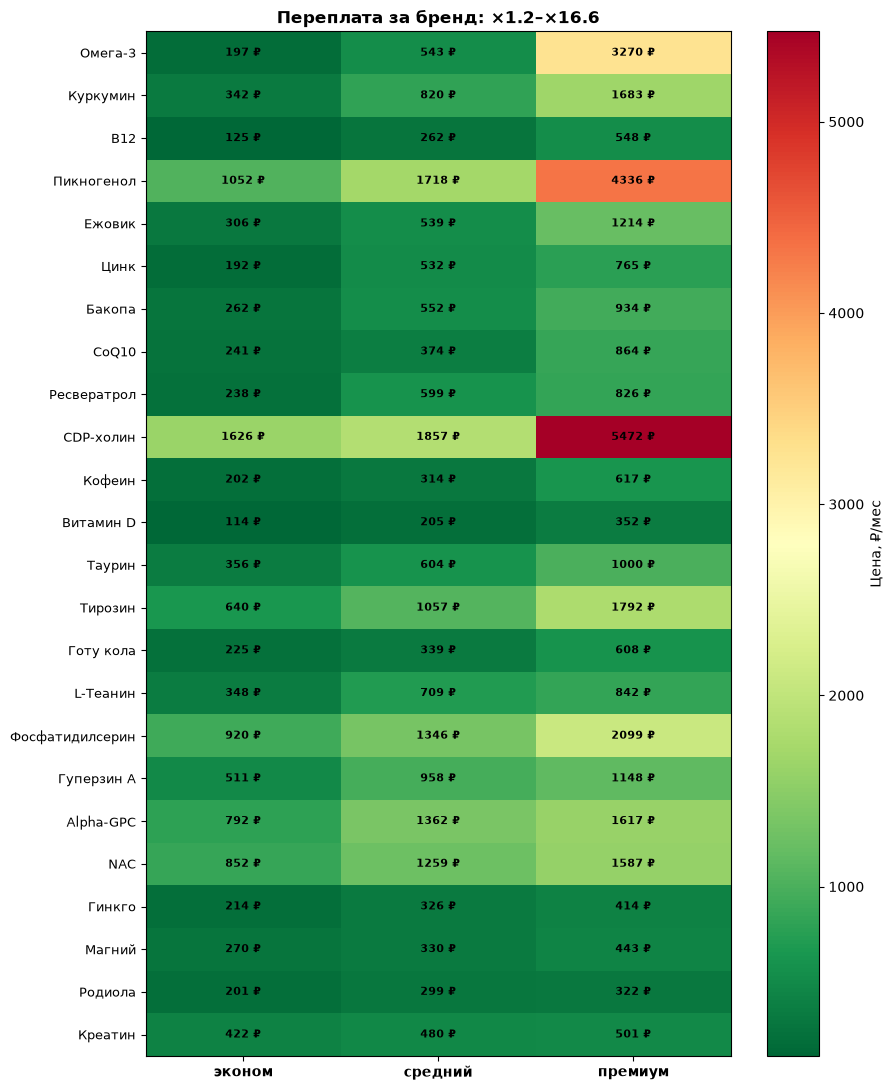

In [7]:
fig, ax = plt.subplots(figsize=(9, 11))
cols = ["эконом", "средний", "премиум"]
im = ax.imshow(tier[cols].values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(cols, fontweight="bold")
ax.set_yticks(range(len(tier))); ax.set_yticklabels(tier.index, fontsize=9)
for i in range(len(tier)):
    for j in range(3):
        v = tier.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{int(v)} ₽", ha="center", va="center",
                    fontsize=8, fontweight="bold")
ax.set_title(f"Переплата за бренд: ×{tier['переплата_в_раз'].min():.1f}–×{tier['переплата_в_раз'].max():.1f}",
             fontweight="bold")
plt.colorbar(im, ax=ax, label="Цена, ₽/мес")
plt.tight_layout()
plt.savefig(REP / "heatmap_tiers.png", dpi=150, bbox_inches="tight")
plt.show()

Пустышки: 20064 ₽/год | Рабочие: 15336 ₽/год | ЭКОНОМИЯ: 4728 ₽/год


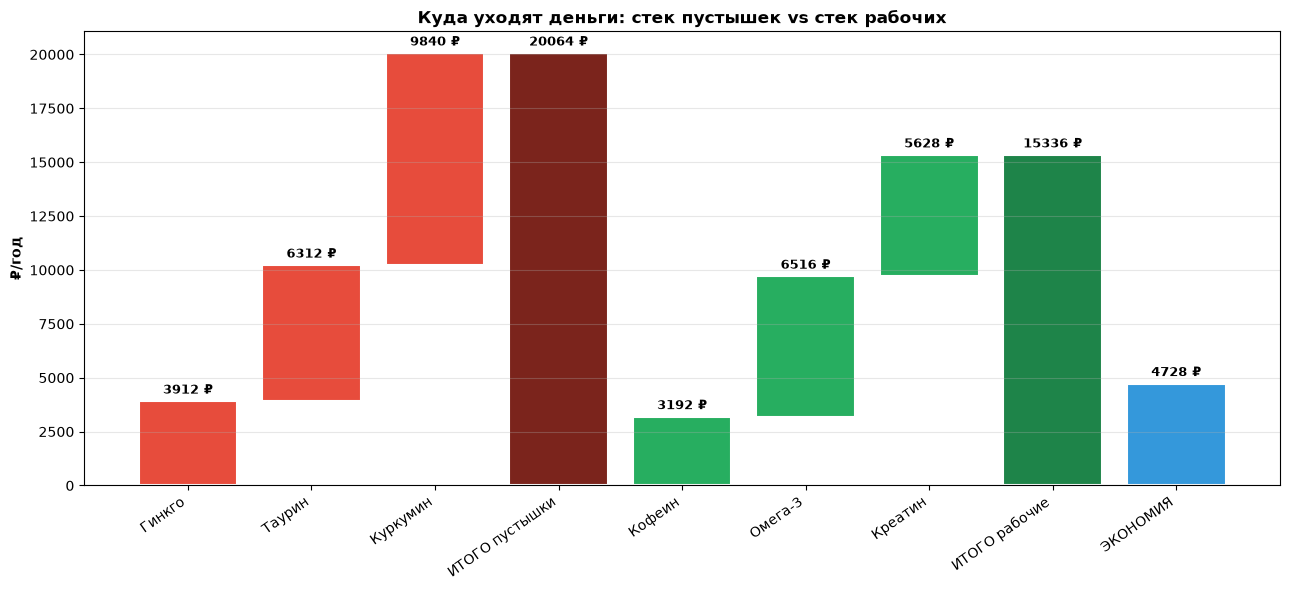

In [8]:
df, trash, gold, save = economics.savings_summary(df, wb)
print("Пустышки:", int(trash["цена_год"].sum()), "₽/год |",
      "Рабочие:", int(gold["цена_год"].sum()), "₽/год |",
      "ЭКОНОМИЯ:", save, "₽/год")

labels, bottoms, heights, clrs = [], [], [], []
cum = 0
for _, r in trash.iterrows():
    labels.append(r["добавка"]); heights.append(r["цена_год"])
    bottoms.append(cum); clrs.append("#e74c3c"); cum += r["цена_год"]
labels.append("ИТОГО пустышки"); heights.append(cum); bottoms.append(0); clrs.append("#7b241c"); t = cum
cum = 0
for _, r in gold.iterrows():
    labels.append(r["добавка"]); heights.append(r["цена_год"])
    bottoms.append(cum); clrs.append("#27ae60"); cum += r["цена_год"]
labels.append("ИТОГО рабочие"); heights.append(cum); bottoms.append(0); clrs.append("#1e8449"); g = cum
labels.append("ЭКОНОМИЯ"); heights.append(t-g); bottoms.append(0); clrs.append("#3498db")

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(labels, heights, bottom=bottoms, color=clrs, edgecolor="white", linewidth=1.5)
for x, (h, b) in enumerate(zip(heights, bottoms)):
    ax.text(x, b+h+350, f"{int(h)} ₽", ha="center", fontweight="bold", fontsize=9)
ax.set_ylabel("₽/год", fontweight="bold")
ax.set_title("Куда уходят деньги: стек пустышек vs стек рабочих", fontweight="bold")
plt.xticks(rotation=35, ha="right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(REP / "waterfall_savings.png", dpi=150, bbox_inches="tight")
plt.show()